<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/work/12_before_after_learning_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day21 학습 전후 비교 실습

- Source: Google Drive `Day21/4-1.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


Before Learning
Initial Parameter
[0.1 0.1 0.1 0.1]

Initial Prediction
0.9900332889206211

Initial Loss
0.036112650897988256
After Learning
Optimal Parameter
[-0.48440423 -0.44174006  1.0715174   1.32758845]

Final Prediction
0.800005184443225

Final Loss
2.6878451552710818e-11
Prediction Comparison
Target              : 0.8000
Initial Prediction  : 0.9900
Final Prediction    : 0.8000

Initial Error       : 0.1900
Final Error         : 0.0000
Loss Comparison
Initial Loss        : 0.036113
Final Loss          : 0.000000
Loss Reduction      : 0.036113
Reduction Rate      : 100.00%
Parameter Comparison
Theta 0 : 0.1000  ->  -0.4844
Theta 1 : 0.1000  ->  -0.4417
Theta 2 : 0.1000  ->  1.0715
Theta 3 : 0.1000  ->  1.3276
Item                Before         After          
Prediction          0.9900         0.8000         
Loss                0.036113       0.000000       
Error               0.1900         0.0000         


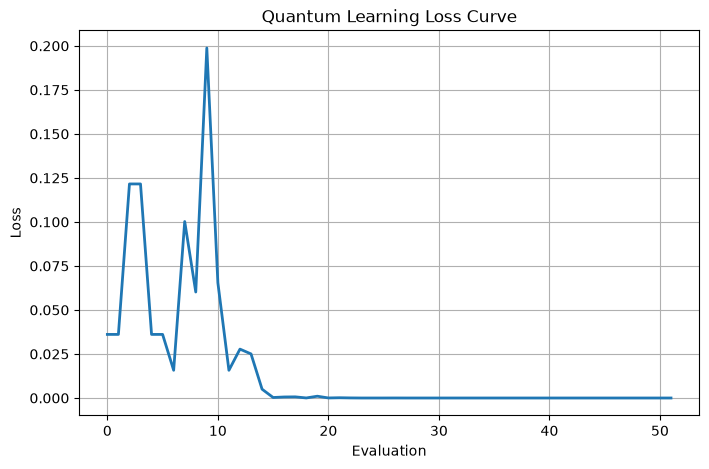

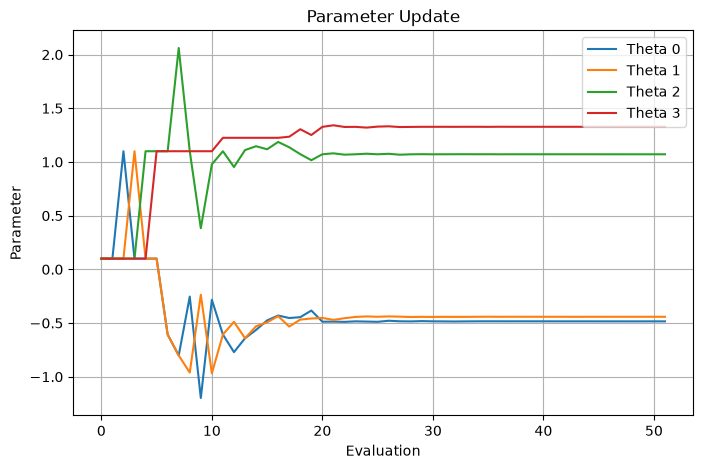

Training Result
학습 성공

Evaluation Count : 50
Final Loss       : 0.000000


In [1]:
"""
============================================================
Lab. 학습 전과 학습 후 결과 비교
============================================================
"""


import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

from qiskit.quantum_info import Statevector
from qiskit.quantum_info import SparsePauliOp

from qiskit_algorithms.optimizers import COBYLA

TARGET = 0.8

theta = ParameterVector("θ", 4)

qc = QuantumCircuit(2)

qc.ry(theta[0], 0)
qc.ry(theta[1], 1)

qc.cx(0, 1)

qc.rz(theta[2], 0)
qc.rz(theta[3], 1)

observable = SparsePauliOp.from_list(
    [("ZI", 1)]
)

def predict(parameter):

    bind = dict(zip(theta, parameter))

    state = Statevector.from_instruction(
        qc.assign_parameters(bind)
    )

    prediction = np.real(
        state.expectation_value(observable)
    )

    return prediction


loss_history = []
parameter_history = []

def loss_function(parameter):

    prediction = predict(parameter)

    loss = (prediction - TARGET) ** 2

    loss_history.append(loss)
    parameter_history.append(parameter.copy())

    return loss

initial_parameter = np.array(
    [0.1, 0.1, 0.1, 0.1]
)

initial_prediction = predict(initial_parameter)

initial_loss = loss_function(initial_parameter)


print("=" * 60)
print("Before Learning")
print("=" * 60)

print("Initial Parameter")
print(initial_parameter)

print()

print("Initial Prediction")
print(initial_prediction)

print()

print("Initial Loss")
print(initial_loss)

optimizer = COBYLA(maxiter=80)

result = optimizer.minimize(
    fun=loss_function,
    x0=initial_parameter
)


# ====================================
# Optimizer 결과 추출
# ====================================

optimal_parameter = result.x

final_prediction = predict(
    optimal_parameter
)

final_loss = loss_function(
    optimal_parameter
)


print("=" * 60)
print("After Learning")
print("=" * 60)

print("Optimal Parameter")
print(optimal_parameter)

print()

print("Final Prediction")
print(final_prediction)

print()

print("Final Loss")
print(final_loss)

prediction_error_before = abs(
    initial_prediction - TARGET
)

prediction_error_after = abs(
    final_prediction - TARGET
)

print("=" * 60)
print("Prediction Comparison")
print("=" * 60)

print(f"Target              : {TARGET:.4f}")

print(f"Initial Prediction  : {initial_prediction:.4f}")

print(f"Final Prediction    : {final_prediction:.4f}")

print()

print(f"Initial Error       : {prediction_error_before:.4f}")

print(f"Final Error         : {prediction_error_after:.4f}")

loss_reduction = initial_loss - final_loss

loss_reduction_rate = (
    loss_reduction / initial_loss
) * 100

print("=" * 60)
print("Loss Comparison")
print("=" * 60)

print(f"Initial Loss        : {initial_loss:.6f}")

print(f"Final Loss          : {final_loss:.6f}")

print(f"Loss Reduction      : {loss_reduction:.6f}")

print(f"Reduction Rate      : {loss_reduction_rate:.2f}%")


print("=" * 60)
print("Parameter Comparison")
print("=" * 60)

for i in range(len(initial_parameter)):

    print(
        f"Theta {i} : "
        f"{initial_parameter[i]:.4f}"
        f"  ->  "
        f"{optimal_parameter[i]:.4f}"
    )

print("=" * 75)

print("{:<20}{:<15}{:<15}".format(
    "Item",
    "Before",
    "After"
))

print("=" * 75)

print("{:<20}{:<15.4f}{:<15.4f}".format(
    "Prediction",
    initial_prediction,
    final_prediction
))

print("{:<20}{:<15.6f}{:<15.6f}".format(
    "Loss",
    initial_loss,
    final_loss
))

print("{:<20}{:<15.4f}{:<15.4f}".format(
    "Error",
    prediction_error_before,
    prediction_error_after
))

plt.figure(figsize=(8,5))

plt.plot(
    loss_history,
    linewidth=2
)

plt.xlabel("Evaluation")

plt.ylabel("Loss")

plt.title("Quantum Learning Loss Curve")

plt.grid(True)

plt.show()


parameter_array = np.array(parameter_history)

plt.figure(figsize=(8,5))

for i in range(parameter_array.shape[1]):

    plt.plot(
        parameter_array[:, i],
        label=f"Theta {i}"
    )

plt.xlabel("Evaluation")

plt.ylabel("Parameter")

plt.title("Parameter Update")

plt.legend()

plt.grid(True)

plt.show()

print("=" * 60)
print("Training Result")
print("=" * 60)

if final_loss < initial_loss:

    print("학습 성공")

else:

    print("학습 실패")

print()

print(
    f"Evaluation Count : {result.nfev}"
)

print(
    f"Final Loss       : {result.fun:.6f}"
)


























